In [31]:
import pandas as pd


In [32]:
customer = pd.read_csv("customers.csv")
sales = pd.read_csv("sales.csv")
store = pd.read_csv("stores.csv")
product = pd.read_csv("products.csv")

In [33]:
customer.head()
customer.shape

(50000, 5)

In [34]:
sales['order_date'] = pd.to_datetime(sales['order_date'])
customer['join_date'] = pd.to_datetime(customer['join_date'])

In [35]:
sales.info()
sales.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   order_id     1000000 non-null  object        
 1   order_date   1000000 non-null  datetime64[ns]
 2   product_id   1000000 non-null  object        
 3   store_id     1000000 non-null  object        
 4   customer_id  1000000 non-null  object        
 5   quantity     1000000 non-null  int64         
 6   unit_price   1000000 non-null  float64       
 7   discount     1000000 non-null  float64       
 8   revenue      1000000 non-null  float64       
 9   cost         1000000 non-null  float64       
 10  profit       1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 83.9+ MB


,order_date,quantity,unit_price,discount,revenue,cost,profit
count,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2023-12-31 19:03:34.991998720,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565
min,2023-01-01 00:00:00,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000
25%,2023-07-02 00:00:00,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000
50%,2024-01-01 00:00:00,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000
75%,2024-07-02 00:00:00,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000
max,2024-12-31 00:00:00,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000
std,NaN,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760


In [36]:
sales['calc_revenue'] = sales['quantity'] * sales['unit_price'] * (1 - sales['discount'])

sales[['revenue', 'calc_revenue']].head()

,revenue,calc_revenue
0,61.33,61.3275
1,36.03,36.0300
2,20.04,20.0400
3,26.39,26.3880
4,12.34,12.3400


In [37]:
sales['calc_profit'] = sales['revenue'] - sales['cost']
sales[['profit','calc_profit']].head()

,profit,calc_profit
0,18.56,18.56
1,16.97,16.97
2,9.75,9.75
3,10.04,10.04
4,4.40,4.40


In [38]:
top_products = sales.groupby('product_id')['quantity'].sum().sort_values(ascending=False)
print(top_products.head())

product_id
P0107    15468
P0091    15457
P0021    15364
P0010    15333
P0008    15327
Name: quantity, dtype: int64


In [39]:
merged = sales.merge(store, on='store_id')

sales_country = merged.groupby('country')['revenue'].sum()
print(sales_country)

country
Australia    3834803.40
Canada       5085319.05
France       4339730.90
Germany      3061163.27
UK           4823617.98
USA          4341494.26
Name: revenue, dtype: float64


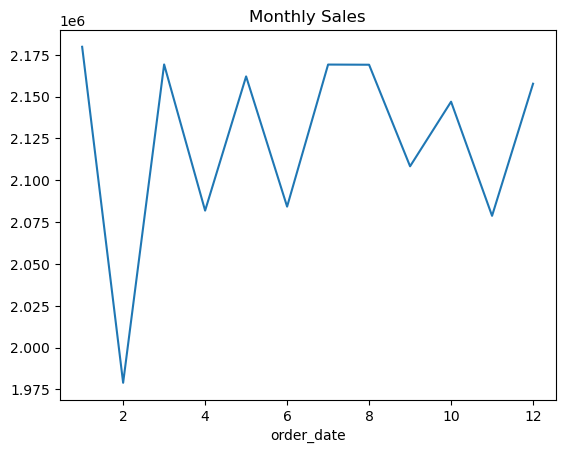

In [40]:
import matplotlib.pyplot as plt
sales.groupby(sales['order_date'].dt.month)['revenue'].sum().plot()
plt.title("Monthly Sales")
plt.show()

In [42]:
customer_sales = sales.groupby('customer_id').agg({
        'revenue' : 'sum' ,
        'order_id' : 'count'
}).reset_index()

customer_sales.columns=['customer_id' , 'total_spendeing' , 'total_orders']

# تقسيم بسيط
customer_sales['segment'] = 'Low'
customer_sales.loc[customer_sales['total_spendeing'] > 100, 'segment'] = 'Medium'
customer_sales.loc[customer_sales['total_spendeing'] > 300, 'segment'] = 'High'

In [45]:
sales.groupby('discount').agg({
    'revenue' : 'mean' ,
    'profit' : 'mean'
  })
sales[['revenue','profit']].head()

,revenue,profit
0,61.33,18.56
1,36.03,16.97
2,20.04,9.75
3,26.39,10.04
4,12.34,4.40


In [54]:
import numpy as np
q1 = sales['profit'].quantile(0.25)
q3 = sales['profit'].quantile(0.75)
iqr = q3 - q1

lower = q1 - (1.5*iqr)
upper = q3 + (1.5*iqr)

outiers_profit = sales[(sales['profit']>=upper) & (sales['profit']<=lower) ]

r1 = sales['revenue'].quantile(0.25)
r3 = sales['revenue'].quantile(0.75)
r = r3 - r1
lo = r1-(1.5*r)
up = r3+(1.5*r)

outiers_revenue=sales[(sales['revenue']>=up)&(sales['revenue']<=lo)]

c1 = sales['cost'].quantile(0.25)
c3 = sales['cost'].quantile(0.75)
c = r3 - r1
low = c1-(1.5*c)
upp = c3+(1.5*c)

outiers_cost=sales[(sales['cost']>=upp)&(sales['cost']<=low)]

print("Number of outliers_profit :" , len(outiers_profit))
print("Number of outiers_revenue :" , len(outiers_revenue))
print("Number of outiers_cost :" , len(outiers_cost))

Number of outliers_profit : 0
Number of outiers_revenue : 0
Number of outiers_cost : 0


In [52]:
sales.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,calc_revenue,calc_profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,61.3275,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,36.0300,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,20.0400,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,26.3880,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,12.3400,4.40


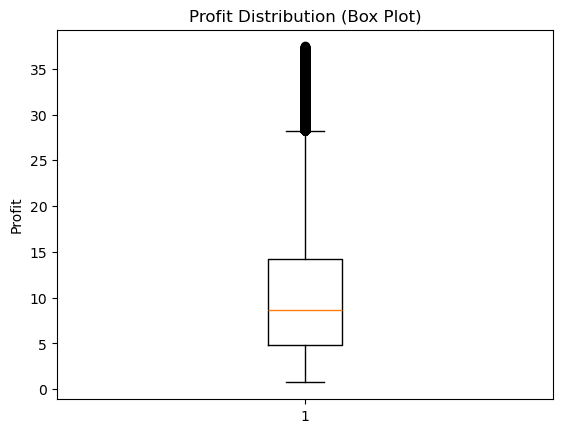

In [49]:


plt.boxplot(sales['profit'])
plt.title("Profit Distribution (Box Plot)")
plt.ylabel("Profit")
plt.show()

In [51]:
from statsmodels.tsa.arima.model import ARIMA

monthly_sales = sales.groupby(sales['order_date'].dt.to_period('M'))['revenue'].sum()

model = ARIMA(monthly_sales, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=3)
print(forecast)

2025-01    1.069466e+06
2025-02    1.074403e+06
2025-03    1.071271e+06
Freq: M, Name: predicted_mean, dtype: float64
